# Higher moment estimation

Mean–variance optimisation only looks at the first two moments. But asset returns are skewed
and fat-tailed, and risk measures like `NegativeSkewness` and `Kurtosis` need
estimates of the **coskewness** and **cokurtosis** tensors to capture that. These high-order
moments are even harder to estimate than the covariance: the cokurtosis matrix is
$N^2 \times N^2$, so with a short window it is wildly over-parametrised and numerically
near-singular. As with the covariance, **denoising and sparsification** rescue it.

In `PortfolioOptimisers` the high-order moments live in a `HighOrderPriorEstimator`,
which wraps a low-order prior and adds a `Coskewness` (`ske`) and `Cokurtosis`
(`kte`) estimator. Each accepts the same `MatrixProcessing` pipeline — `Denoise`
and `LoGo` — that we apply to covariances.

> **When to reach for this**
>
> Reach for high-order moment estimation whenever you optimise against a skew- or
> tail-sensitive risk measure (`NegativeSkewness`, `Kurtosis`, and the
> square-root variants), or build a Pareto surface over them. And reach for *denoised*
> high-order moments essentially always when you do: the raw cokurtosis on a short window is
> numerically singular, so denoising is what makes these optimisations well-posed rather than
> a nicety. If you only use variance/tail measures that need no tensors, skip it.

In [1]:
using PortfolioOptimisers, PrettyTables, LinearAlgebra

hmmtfmt = (v, i, j) -> begin
    if j == 1
        return v
    else
        return isa(v, Number) ? "$(round(v, digits=6))" : v
    end
end;
resfmt = (v, i, j) -> begin
    if j == 1
        return v
    else
        return isa(v, Number) ? "$(round(v*100, digits=3)) %" : v
    end
end;

## 1. ReturnsResult data

We use the same S&P 500 slice as the other examples.

In [2]:
using CSV, TimeSeries, DataFrames

X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
rd = prices_to_returns(X)

ReturnsResult
    nx ┼ 20-element Vector{String}
     X ┼ 252×20 Matrix{Float64}
    nf ┼ nothing
     F ┼ nothing
    nb ┼ nothing
     B ┼ nothing
    ts ┼ 252-element Vector{Date}
    iv ┼ nothing
  ivpa ┴ nothing


## 2. High-order priors

We build three high-order priors that differ only in how the coskewness and cokurtosis are
processed: raw (vanilla), `FixedDenoise`d, and `LoGo`-sparsified. We then
compare the condition numbers of the coskewness negative-spectral-slice matrix `V` and the
cokurtosis matrix `kt`.

In [3]:
hopes = ["Vanilla" => HighOrderPriorEstimator(),
         "Denoise" => HighOrderPriorEstimator(;
                                              ske = Coskewness(;
                                                               mp = MatrixProcessing(;
                                                                                     dn = Denoise(;
                                                                                                  alg = FixedDenoise()))),
                                              kte = Cokurtosis(;
                                                               mp = MatrixProcessing(;
                                                                                     dn = Denoise(;
                                                                                                  alg = FixedDenoise())))),
         "LoGo" => HighOrderPriorEstimator(;
                                           ske = Coskewness(;
                                                            mp = MatrixProcessing(;
                                                                                  dn = Denoise(),
                                                                                  alg = LoGo())),
                                           kte = Cokurtosis(;
                                                            mp = MatrixProcessing(;
                                                                                  dn = Denoise(),
                                                                                  alg = LoGo())))]

prs = [k => prior(pe, rd) for (k, pe) in hopes]

3-element Vector{Pair{String}}:
 "Vanilla" => HighOrderPrior
    pr ┼ LowOrderPrior
       │         X ┼ 252×20 Matrix{Float64}
       │        mu ┼ 20-element Vector{Float64}
       │     sigma ┼ 20×20 Matrix{Float64}
       │      chol ┼ nothing
       │         w ┼ nothing
       │       ens ┼ nothing
       │       kld ┼ nothing
       │        ow ┼ nothing
       │        rr ┼ nothing
       │      f_mu ┼ nothing
       │   f_sigma ┼ nothing
       │       f_w ┴ nothing
    kt ┼ 400×400 Matrix{Float64}
    D2 ┼ 400×210 SparseArrays.SparseMatrixCSC{Int64, Int64}
    L2 ┼ 210×400 SparseArrays.SparseMatrixCSC{Int64, Int64}
    S2 ┼ 210×400 SparseArrays.SparseMatrixCSC{Int64, Int64}
    sk ┼ 20×400 Matrix{Float64}
     V ┼ 20×20 Matrix{Float64}
  skmp ┼ MatrixProcessing
       │     pdm ┼ Posdef
       │         │      alg ┼ UnionAll: NearestCorrelationMatrix.Newton
       │         │   kwargs ┴ @NamedTuple{}: NamedTuple()
       │      dn ┼ nothing
       │      dt ┼ nothing
       │

The condition numbers tell the whole story. The raw cokurtosis is numerically singular (a
condition number of order $10^{15}$); denoising and sparsification bring it down by many
orders of magnitude, turning an ill-posed optimisation into a stable one.

In [4]:
pretty_table(DataFrame(; :estimator => [k for (k, _) in prs],
                       Symbol("cond(V) coskew") => [cond(p.V) for (_, p) in prs],
                       Symbol("cond(kt) cokurt") => [cond(p.kt) for (_, p) in prs]);
             formatters = [hmmtfmt], title = "High-order moment conditioning")

           High-order moment conditioning
┌───────────┬────────────────┬──────────────────────┐
│ estimator │ cond(V) coskew │      cond(kt) cokurt │
│    String │        Float64 │              Float64 │
├───────────┼────────────────┼──────────────────────┤
│   Vanilla │     129.142244 │ 1.876488344262381e15 │
│   Denoise │      67.938603 │         18069.363314 │
│      LoGo │      86.422416 │         25890.135292 │
└───────────┴────────────────┴──────────────────────┘


## 3. Visualising the high-order moments

The coskewness and cokurtosis heatmaps show the denoising at work — the raw matrices are dense
and noisy, the processed ones cleaner and better conditioned.

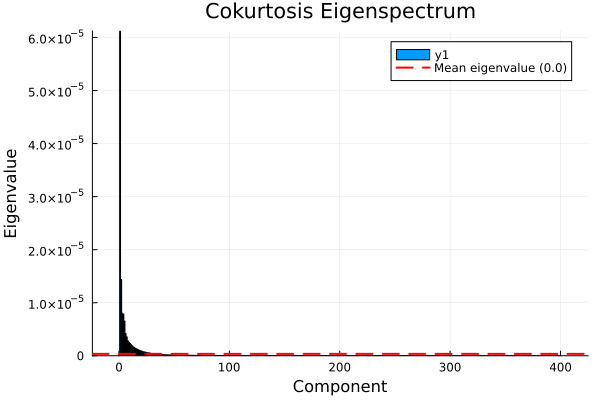

In [5]:
using StatsPlots, GraphRecipes#= Coskewness heatmap: vanilla vs denoised. =#

plot_coskewness(prs[1].second, rd)#= Coskewness heatmap: denoised. =#

plot_coskewness(prs[2].second, rd)#= Cokurtosis eigenspectrum: vanilla vs denoised. =#

plot_cokurtosis(prs[1].second, rd)#= Cokurtosis eigenspectrum: denoised. =#

plot_cokurtosis(prs[2].second, rd)

## 4. Why it matters: skew- and tail-aware optimisation

We minimise two high-order risk measures — `NegativeSkewness` and `Kurtosis` —
using each high-order prior. With the raw (near-singular) tensors the solver is working against
a degenerate problem; the denoised and sparsified priors give stable, sensible allocations.

In [6]:
using Clarabel

slv = Solver(; name = :clarabel1, solver = Clarabel.Optimizer,
             settings = Dict("verbose" => false),
             check_sol = (; allow_local = true, allow_almost = true))

ress_sk = [k => optimise(MeanRisk(; r = NegativeSkewness(), obj = MinimumRisk(),
                                  opt = JuMPOptimiser(; pe = p, slv = slv)))
           for (k, p) in prs]
ress_kt = [k => optimise(MeanRisk(; r = Kurtosis(), obj = MinimumRisk(),
                                  opt = JuMPOptimiser(; pe = p, slv = slv)))
           for (k, p) in prs]

pretty_table(DataFrame(["Assets" => rd.nx;
                        ["NSkew $k" => r.w for (k, r) in ress_sk];
                        ["Kurt $k" => r.w for (k, r) in ress_kt]]); formatters = [resfmt],
             title = "Minimum skew / kurtosis weights by prior")

                    Minimum skew / kurtosis weights by prior
┌────────┬───────────────┬───────────────┬────────────┬──────────────┬──────────
│ Assets │ NSkew Vanilla │ NSkew Denoise │ NSkew LoGo │ Kurt Vanilla │ Kurt De ⋯
│ String │       Float64 │       Float64 │    Float64 │      Float64 │      Fl ⋯
├────────┼───────────────┼───────────────┼────────────┼──────────────┼──────────
│   AAPL │         0.0 % │       2.907 % │    2.566 % │        0.0 % │         ⋯
│    AMD │         0.0 % │         0.0 % │      0.0 % │        0.0 % │         ⋯
│    BAC │      15.073 % │      14.784 % │    24.03 % │        0.0 % │         ⋯
│    BBY │         0.0 % │         0.0 % │      0.0 % │        0.0 % │         ⋯
│    CVX │       5.941 % │       4.424 % │    0.474 % │        0.0 % │      0. ⋯
│     GE │         0.0 % │         0.0 % │      0.0 % │      1.548 % │      1. ⋯
│     HD │         0.0 % │         0.0 % │      0.0 % │      2.616 % │      2. ⋯
│    JNJ │      16.214 % │      19.119 % │   12.

The composition plot contrasts the negative skew-minimising portfolios across the three priors.

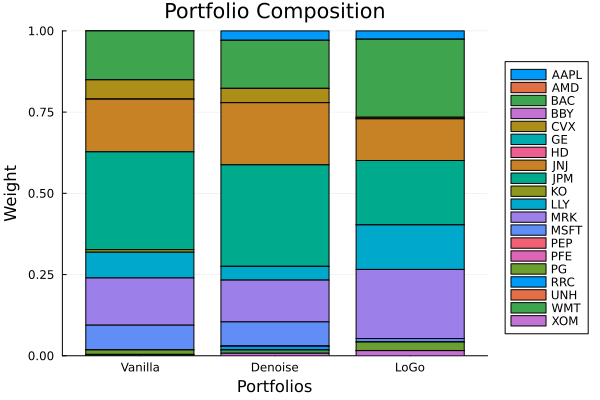

In [7]:
plot_stacked_bar_composition([r for (_, r) in ress_sk], rd;
                             xticks = (1:length(ress_sk), [k for (k, _) in ress_sk]))

The composition plot contrasts the kurtosis-minimising portfolios across the three priors.

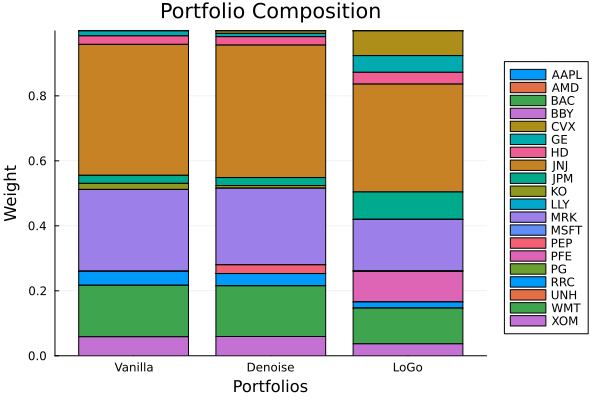

In [8]:
plot_stacked_bar_composition([r for (_, r) in ress_kt], rd;
                             xticks = (1:length(ress_kt), [k for (k, _) in ress_kt]))

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*